<a href="https://colab.research.google.com/github/jiannyuhs-hue/ADALL_github/blob/main/3013570Y_ADALL_Practical_Test_Vehicle_Sales_Question.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ADALL Practical Test – Regression (Vehicle Sales)

**Dataset:** `syedanwarafridi/vehicle-sales-data` → `car_prices.csv`  
**Goal:** Build a regression model to predict **selling price** using basic vehicle attributes.

## Guide for this practical test
- Focus on a **clear workflow**
- Keep code **readable** and **stable**.
- Answer short questions in **markdown** cells.
- You may run cells step-by-step and check outputs.

##Data Dictionary

sellingprice:
The price at which the vehicle was sold.

year: The manufacturing year of the vehicle.

make:
The brand or manufacturer of the vehicle.

model:
The specific model of the vehicle.

body:
The body type of the vehicle (e.g., SUV, Sedan).

transmission:
The type of transmission in the vehicle (e.g., automatic).

odometer:
The mileage or distance traveled by the vehicle.

condition:
Condition of the vehicle, rated on a scale.



## Section 0) Setup

This notebook uses **kagglehub** to download the dataset directly into Colab.

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

##Section 1) Download and load the dataset.
###Run the following code exactly as shown for Section 1. Do not edit it, or your results and answers may differ from the expected output.

In [8]:
import kagglehub
path = kagglehub.dataset_download("syedanwarafridi/vehicle-sales-data")
print("Downloaded to:", path)
print("Files:", os.listdir(path))
csv_path = os.path.join(path, "car_prices.csv")
df = pd.read_csv(csv_path)

Using Colab cache for faster access to the 'vehicle-sales-data' dataset.
Downloaded to: /kaggle/input/vehicle-sales-data
Files: ['car_prices.csv']


In [9]:
target_col = "sellingprice"
feature_cols = [
    "year",
    "make",
    "model",
    "body",
    "transmission",
    "odometer",
    "condition",
]
df = df[feature_cols + [target_col]].copy()
df = df.dropna()
df = df.sample(5000, random_state=42)

##Section 2) Inspection + AI-assisted cleaning

**Important Note**
- You are free to modify the given code in this section, including the following block, such as adding additional queries, as you deem necessary.
- You do not need to submit this block of modified code, if applicable.



In [13]:
import pandas as pd
import numpy as np
from io import StringIO

# ---------------------------
# Generate a full dataset profile
# ---------------------------

buffer = StringIO()

# dtypes
buffer.write("=== DTYPES ===\n")
buffer.write(df.dtypes.to_string())
buffer.write("\n\n")

# numeric describe
buffer.write("=== NUMERIC DESCRIBE ===\n")
buffer.write(df.describe().to_string())
buffer.write("\n\n")

# categorical describe
buffer.write("=== CATEGORICAL DESCRIBE ===\n")
try:
    buffer.write(df.describe(include='object').to_string())
except:
    buffer.write("No categorical columns")
buffer.write("\n\n")

# null summary
buffer.write("=== NULL SUMMARY ===\n")
null_summary = (
    df.isna().sum().to_frame("null_count")
    .assign(null_pct=lambda x: x["null_count"]/len(df))
)
buffer.write(null_summary.to_string())
buffer.write("\n\n")

# outlier summary
buffer.write("=== OUTLIER SUMMARY (IQR METHOD) ===\n")
num_cols = df.select_dtypes(include=['number']).columns  # exclude booleans
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[num_cols] < (Q1 - 1.5*IQR)) | (df[num_cols] > (Q3 + 1.5*IQR))).sum()
buffer.write(outliers.to_string())
buffer.write("\n\n")

# shape, duplicates, constant cols
buffer.write("=== SHAPE / DUPLICATES / CONSTANT COLUMNS ===\n")
dup_count = df.duplicated().sum()
constant_cols = df.columns[df.nunique() == 1].tolist()
buffer.write(f"Rows: {len(df)}, Columns: {df.shape[1]}\n")
buffer.write(f"Duplicate rows: {dup_count}\n")
buffer.write(f"Constant columns: {constant_cols}\n\n")

# Unique values per column
buffer.write("=== UNIQUE VALUES PER COLUMN ===\n")
unique_table = pd.DataFrame()
unique_table['unique_count'] = df.nunique(dropna=False)
buffer.write(unique_table.to_string())
buffer.write("\n\n")

# Top 10 values for categorical columns
buffer.write("=== TOP 10 VALUES FOR CATEGORICAL COLUMNS ===\n")

categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

if len(categorical_columns) == 0:
    buffer.write("No categorical columns found.\n")
else:
    for col in categorical_columns:
        buffer.write("\nColumn:" + col + "\n")
        buffer.write(df[col].value_counts(dropna=False).head(10).to_string())
        buffer.write("\n")

buffer.write("\n")

# Correlation between numeric columns
buffer.write("=== CORRELATION BETWEEN NUMERIC COLUMNS ===\n")
correlation_table = df.corr(numeric_only=True).round(2)
buffer.write(correlation_table.to_string())
buffer.write("\n\n'")

# Simple warning checks
buffer.write("=== SIMPLE WARNING CHECKS ===\n")

id_like_columns = []
constant_columns = []

for col in df.columns:
    unique_count = df[col].nunique(dropna=False)

    if unique_count == len(df):
        id_like_columns.append(col)

    if unique_count <= 1:
        constant_columns.append(col)

buffer.write("Possible ID-like columns: " + str(id_like_columns) + "\n")
buffer.write("Constant columns:" + str(constant_columns) + "\n")
buffer.write("Duplicate rows: " + str(df.duplicated().sum()) + "\n")

# Final text
payload_text = buffer.getvalue()

print(payload_text)

=== DTYPES ===
year              int64
make             object
model            object
body             object
transmission     object
odometer        float64
condition       float64
sellingprice    float64

=== NUMERIC DESCRIBE ===
              year       odometer   condition   sellingprice
count  5000.000000    5000.000000  5000.00000    5000.000000
mean   2010.236800   67335.086600    30.78680   13773.646000
std       3.742129   51236.131912    13.28692    9522.803444
min    1991.000000       1.000000     1.00000     200.000000
25%    2008.000000   28759.500000    24.00000    7200.000000
50%    2012.000000   52177.000000    34.50000   12300.000000
75%    2013.000000   96431.000000    41.00000   18300.000000
max    2015.000000  380347.000000    49.00000  111000.000000

=== CATEGORICAL DESCRIBE ===
        make   model   body transmission
count   5000    5000   5000         5000
unique    43     449     48            2
top     Ford  Altima  Sedan    automatic
freq     850     173   1

In [15]:
RUN_API_CELLS = True
OPENAI_MODEL = 'gpt-5.4-nano'
client = None

from google.colab import userdata
from openai import OpenAI

# Load key from Google Colab Secrets
api_key = userdata.get('OPENAI_API_KEY')

client = OpenAI(
    api_key=api_key,
)

##Task for question 1 and 2

1. Create a request using the OpenAI API client.
2. Use client.responses.create with appropriate instructions and input to request the necessary steps and code for data cleaning BEFORE performing encoding.
3. Copy your request code to Politemall Q1 (15 points)
4. Copy GenAI recommended code to 2 blocks below. You are required to review and modify if necessary.
4. Copy your modified GenAI response and add your written review for each recommendations returned by the model to Politemall Q2 (15 points)

In [19]:
#---------------------------
#You are encouraged to modify the following:
#---------------------------
response = client.responses.create(
    model="gpt-5.4-nano",
    instructions="""
You are an expert data scientist and prepare a vehicle pricing dataset for modelling..
""",
    input=f"""
Dataset info: {payload_text}\n

Questions:

1. List all data quality (target leakage or lable leakage if presented) or modelling-readiness issues.
2. provide a python script to fix each of the following issues, only for data cleaning purposes, do not model yet.

""")

print(response.output_text)


## 1) Data quality / modelling-readiness issues (including leakage)

### A. Missing values
- **None** (all columns have 0 nulls). ✅ No action needed.

### B. Target leakage / label leakage
- There is **no obvious leakage** from features into `sellingprice` based on the provided schema.
- However, you should still verify the dataset does not contain any **post-sale information** disguised as features. Your current columns are typical vehicle attributes (`year`, `odometer`, `condition`, categoricals), so **risk appears low**.

### C. Outliers / extreme values
Using the IQR summary:
- **`sellingprice`** has **141 outliers** → can strongly affect linear models and sometimes tree models.
- **`odometer`** has **102 outliers**.
- **`year`** has **92 outliers**.
- **`condition`** has **0 outliers** (but may still have scaling issues—see next point).

These aren’t necessarily “wrong”, but they can harm training. You may want:
- cap/winsorize extreme values, or
- flag/remove them (often risky fo

In [20]:
#---------------------------
# Block for running the script recommended by model. Modify as you deem necessary.
# You do not need to copy and paste this block into Politemall.
#---------------------------

def clean_vehicle_pricing_data(
    df: pd.DataFrame,
    target_col: str = "sellingprice",
    iqr_factor: float = 1.5,
    clip_outliers: bool = True,   # safer than dropping for pricing datasets
    drop_invalid_rows: bool = True,
    verbose: bool = True
):
    df = df.copy()

    # -----------------------------
    # 1) Categorical normalization
    # -----------------------------
    cat_cols = ["make", "model", "body", "transmission"]
    for c in cat_cols:
        # ensure string, strip whitespace, collapse internal whitespace
        df[c] = (
            df[c]
            .astype(str)
            .str.strip()
            .str.replace(r"\s+", " ", regex=True)
        )

    # Normalize case:
    # - make/model: Title case often reasonable; model names like "G Sedan" need consistent casing.
    # - body/transmission: Title case to fix Sedan/sedan, SUV/suv.
    # If your data contains brands where Title-casing could be undesirable, restrict to body/transmission only.
    df["make"] = df["make"].str.title()
    df["model"] = df["model"].str.title()
    df["body"] = df["body"].str.title()
    df["transmission"] = df["transmission"].str.lower().str.replace(" ", "", regex=False)

    # Map transmission to canonical values
    # (your dataset shows 'automatic' and 'manual')
    trans_map = {
        "automatic": "automatic",
        "manual": "manual"
    }
    df["transmission"] = df["transmission"].map(trans_map).fillna(df["transmission"])

    # -----------------------------------------
    # 4) Return cleaned df + report (optional)
    # -----------------------------------------
    return df



##Section 3) Inspection after cleaning

As this dataset uses **sellingprice** as the target column, the following blocks in this section are intended to support your success in the practical test. There is no question or task for you to complete in this section. You can run the codes as it is.

In [21]:
print("Shape:", df.shape)

print("\nMissing values:")
display(df.isna().sum())

print("\nSummary:")
display(df.describe(include="all").T)

Shape: (5000, 8)

Missing values:


,0
year,0
make,0
model,0
body,0
transmission,0
odometer,0
condition,0
sellingprice,0



Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,5000.0,NaN,NaN,NaN,2010.2368,3.742129,1991.0,2008.0,2012.0,2013.0,2015.0
make,5000,43,Ford,850,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,5000,449,Altima,173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body,5000,48,Sedan,1794,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,5000,2,automatic,4836,NaN,NaN,NaN,NaN,NaN,NaN,NaN
odometer,5000.0,NaN,NaN,NaN,67335.0866,51236.131912,1.0,28759.5,52177.0,96431.0,380347.0
condition,5000.0,NaN,NaN,NaN,30.7868,13.28692,1.0,24.0,34.5,41.0,49.0
sellingprice,5000.0,NaN,NaN,NaN,13773.646,9522.803444,200.0,7200.0,12300.0,18300.0,111000.0


##Section 4) Train-test split

 There is no question or task for you to complete in this section. You can run the codes as it is.


In [22]:
X = df.drop(columns=[target_col])
y = df[target_col]

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (4000, 7)
Test shape : (1000, 7)


##Section 5) Encoding


##Task for question 3
###Encoding

Use the encoding approach demonstrated in earlier practicals.

Complete the two code blocks below. The comments provide hints about the steps required.

Complete and copy all the codes within this section to Politemall Q3 (15 points)

In [24]:
# Identify the numeric columns in X_train.

# Identify the categorical columns in X_train.

# Print both lists to check your results.

cat_columns = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_columns = X_train.select_dtypes(exclude=['object', 'category']).columns.tolist()

print('Categorical columns:', cat_columns)
print('Numeric columns:', num_columns)

Categorical columns: ['make', 'model', 'body', 'transmission']
Numeric columns: ['year', 'odometer', 'condition']


In [27]:
# Create a ColumnTransformer named preprocessor.

# For numeric columns:
# - pass the values through without encoding
# - apply this step to the numeric-column list created above

# For categorical columns:
# - use the name "cat"
# - apply OneHotEncoder
# - ignore categories that were not found during training
# - apply this step to the categorical-column list created above


# Display the completed preprocessor.

from sklearn.model_selection import train_test_split, ShuffleSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_columns),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop'
)

preprocessor

ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['make', 'model', 'body', 'transmission']),
                                ('num', 'passthrough',
                                 ['year', 'odometer', 'condition'])])

##Section 6) Modelling

Use the following code for the models. You do not need to edit or tune the model.


In [28]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import ShuffleSplit
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
# -------------------------------------------
# 1. Create pipelines for both models
# -------------------------------------------

pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42))
])

pipe_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        random_state=42))
])

# -------------------------------------------
# 2. Define parameter grids
# Keep them small for speed and simplicity
# -------------------------------------------

param_grid_rf = {
  "regressor__n_estimators": [250],
  'regressor__max_depth':[5],
  'regressor__criterion':['squared_error']
}

param_grid_xgb = {
    "regressor__n_estimators": [250],
  'regressor__max_depth':[6],
  'regressor__eval_metric':['rmse']
}

# -------------------------------------------
# 3. Create GridSearchCV objects
# -------------------------------------------

gs_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=3
)

gs_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=3
)

# -------------------------------------------
# 4. Fit both models
# (Students can run one at a time if needed)
# -------------------------------------------e

gs_rf.fit(X_train, y_train)
print("Random Forest grid search complete.")

gs_xgb.fit(X_train, y_train)
print("XGBoost grid search complete.")

# -------------------------------------------
# 5. Evaluate on test set
# -------------------------------------------

from sklearn.metrics import mean_absolute_error

rf_pred = gs_rf.best_estimator_.predict(X_test)
xgb_pred = gs_xgb.best_estimator_.predict(X_test)

print("\nMAE (Random Forest):", mean_absolute_error(y_test, rf_pred))
print("Best RF Params:", gs_rf.best_params_)

print("\nMAE (XGBoost):", mean_absolute_error(y_test, xgb_pred))
print("Best XGB Params:", gs_xgb.best_params_)

Fitting 10 folds for each of 1 candidates, totalling 10 fits
Random Forest grid search complete.
Fitting 10 folds for each of 1 candidates, totalling 10 fits
XGBoost grid search complete.

MAE (Random Forest): 4235.175315730801
Best RF Params: {'regressor__criterion': 'squared_error', 'regressor__max_depth': 5, 'regressor__n_estimators': 250}

MAE (XGBoost): 2123.383811317444
Best XGB Params: {'regressor__eval_metric': 'rmse', 'regressor__max_depth': 6, 'regressor__n_estimators': 250}


##Section 7) Quick diagnostic plot (sorted true vs predicted)

This plot helps you check whether the model follows the overall price pattern.
The same approach can also be applied consistently when reviewing other models during model selection.

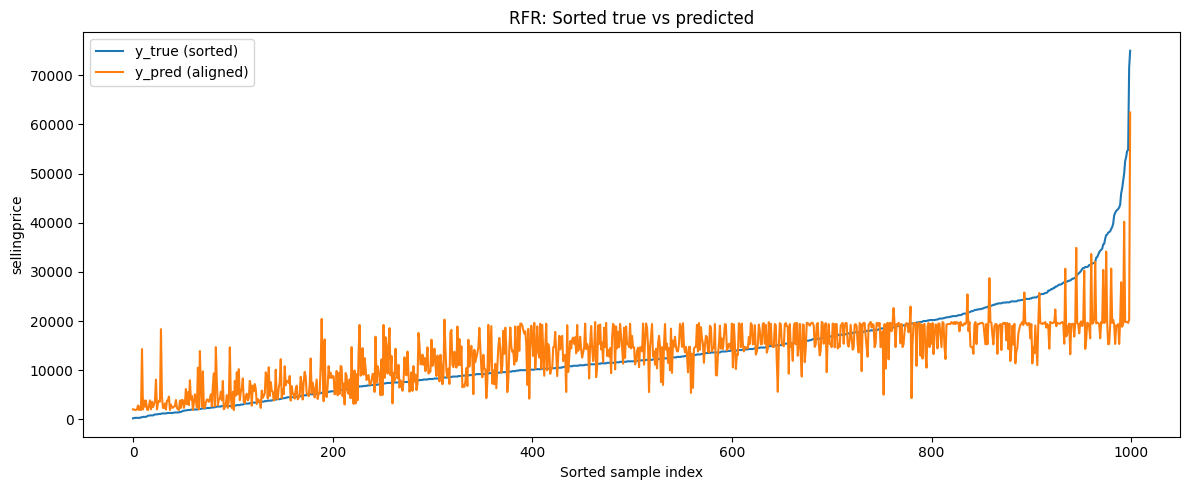

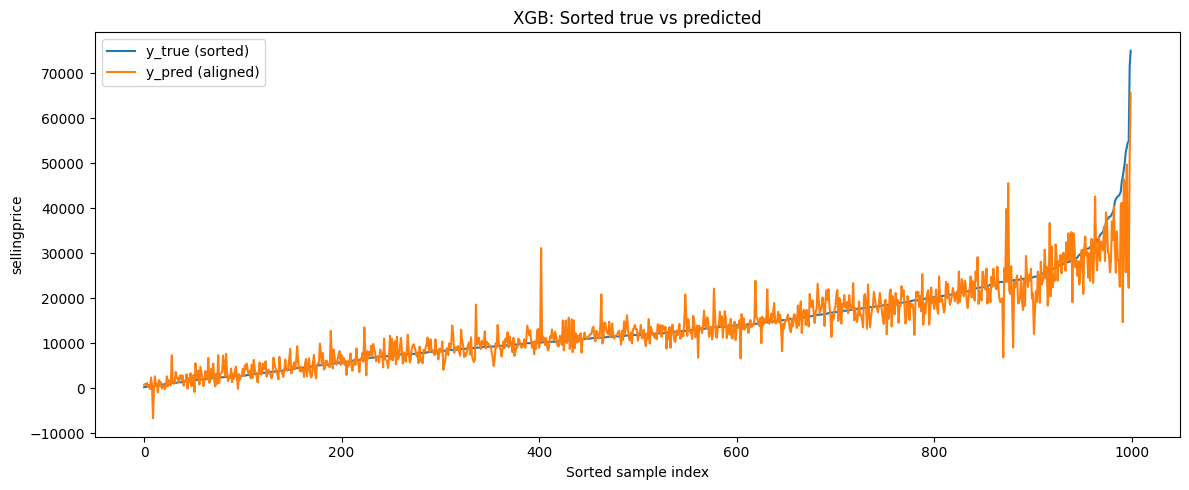

In [29]:
# Helper: plot y_true sorted, with y_pred aligned to same order
def plot_sorted_true_vs_pred(y_true, y_pred, title, xlabel="Sorted sample index"):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    order = np.argsort(y_true)
    y_true_sorted = y_true[order]

    plt.figure(figsize=(12, 5))
    plt.plot(y_true_sorted, label="y_true (sorted)")
    plt.plot(y_pred[order], label="y_pred (aligned)")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("sellingprice")
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_sorted_true_vs_pred(y_test, rf_pred, "RFR: Sorted true vs predicted")
plot_sorted_true_vs_pred(y_test, xgb_pred, "XGB: Sorted true vs predicted")

##Section 8) Model selection


##Task for question 4
### Model selection
See Politemall Q4, for more details (15 points). Save this as ipynb file and attach it to the same question.